# Visualization Exercises Part 4

This is the fourth of several exercise pages on visualization using [Matplotlib](http://matplotlib.org/index.html) that were prepared for use in the course ITSE 1302 at Austin Community College.

The remainder of this exercise page will deal with [scatter](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.scatter.html?highlight=scatter#matplotlib.axes.Axes.scatter) plots.

## Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Utility methods

### Least mean square best fit line

The following function will compute a least mean square best fit line for a scatter plot. Click [here](https://www.varsitytutors.com/hotmath/hotmath_help/topics/line-of-best-fit) to view the source of the algorithm.


In [2]:
def lmsBestFitLine(xDataIn,yDataIn):
    xBar = sum(xDataIn)/len(xDataIn)
    yBar = sum(yDataIn)/len(yDataIn)

    numerator = 0
    for cnt in range(len(xDataIn)):
        numerator += (xDataIn[cnt] - xBar) * (yDataIn[cnt] - yBar)

    denominator = 0
    for cnt in range(len(xDataIn)):
        denominator += (xDataIn[cnt] -xBar)**2

    m = numerator/denominator

    b = yBar - m*xBar
    
    return (m,b)#slope,y-intercept

## Basic scatter plot

Scatter plots are similar to line plots in that they use horizontal and vertical axes to plot data points. However, they have a very specific [purpose](http://mste.illinois.edu/courses/ci330ms/youtsey/scatterinfo.html). Scatter plots show how much one variable is affected by another. The relationship between two variables is called their correlation . 

While that is the most common use of scatter plots, the [Axes.scatter](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.scatter.html?highlight=scatter#matplotlib.axes.Axes.scatter) method takes many arguments and can be used to create visualizations with other purposes as well. Some of those purposes will be discussed on this exercise page.

The following code illustrates a basic scatter plot for three cases:
- Totally correlated
- Partially correlated
- Totally uncorrelated

The scatter plot produced by this code shows the default marker in the default size with the default color.

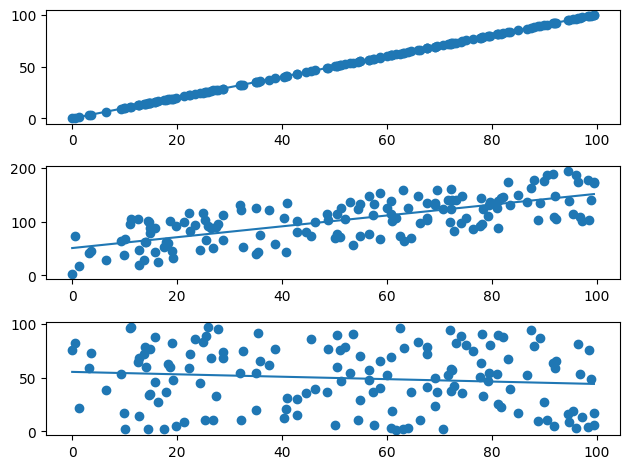

In [3]:
fig,(ax0,ax1,ax2) = plt.subplots(3,1)

x = np.random.uniform(0,100,150)
#====================

#Totally correlated data.
# The two datasets are identical.
yFirst = [x[cnt] for cnt in range(len(x))] 
ax0.scatter(x,yFirst)
#Compute the best fit line
m,b =lmsBestFitLine(x,yFirst)

#Draw a best fit line on the scatter plot
x1 = min(x)
y1 = m*x1 + b
x2 = max(x)
y2 = m*x2 + b
ax0.plot([x1,x2], [y1,y2])
#====================

#Partially correlated data.
# ySecond is equal to x plus random noise.
ySecond = [(x[cnt] + np.random.uniform(0,100)) 
           for cnt in range(len(x))] 
ax1.scatter(x,ySecond)
#Compute the best fit line
m,b =lmsBestFitLine(x,ySecond)

#Draw a best fit line on the scatter plot
x1 = min(x)
y1 = m*x1 + b
x2 = max(x)
y2 = m*x2 + b
ax1.plot([x1,x2], [y1,y2])
#====================

#Totally uncorrelated data.
# x and yThird are uncorrelated datasets
# of random values.
yThird = np.random.uniform(0,100,150)
ax2.scatter(x,yThird)
#Compute the best fit line
m,b =lmsBestFitLine(x,yThird)

#Draw a best fit line on the scatter plot
x1 = min(x)
y1 = m*x1 + b
x2 = max(x)
y2 = m*x2 + b
ax2.plot([x1,x2], [y1,y2])

#====================
plt.tight_layout()
plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.01.png**

### Type of Image
This figure contains three horizontally aligned scatter plots, each showing a different strength of linear relationship between two quantitative variables. Each plot includes blue circular data points and a fitted regression line.

### Overall Summary
The three panels compare strong, moderate, and weak correlations. The top plot shows a tight upward trend, the middle plot shows a more dispersed upward trend, and the bottom plot shows widely scattered points with almost no trend.

### Detailed Description
- The top scatter plot displays a strong positive linear relationship. The points cluster closely around an upward-sloping line extending from the lower left toward the upper right.
- The middle scatter plot shows a moderate positive correlation. The points are more widely dispersed but still follow an upward trend, with the fitted line rising more steeply than in the top plot.
- The bottom scatter plot illustrates little to no correlation. The points are scattered broadly with no clear pattern, and the fitted line is nearly horizontal around the midrange of the vertical axis.

### Purpose of the Image
The figure demonstrates how the strength of a correlation affects the appearance of a scatter plot and the interpretive value of a regression line. It helps students visually connect the concept of correlation strength with the dispersion of data points and the slope of the fitted line.

## Markers and marker size

The [Axes.scatter](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.scatter.html?highlight=scatter#matplotlib.axes.Axes.scatter) method takes several keyword arguments. One of the keyword arguments is named **marker**. This argument specifies the visual symbol or marker that will be drawn at a location determined by given values for x and y. Many markers are available and you will find a list of them [here](http://matplotlib.org/2.0.2/api/markers_api.html#module-matplotlib.markers).

Another keyword parameter is named **s**, which stands for marker size. This is an area measurement specified in <a href="https://en.wikipedia.org/wiki/Point_(typography)">points</a> squared. In other words, an s-value of 225 represents a marker with horizontal and vertical dimensions of 25 points each, because 25 squared is 225. In case you are unfamiliar with the term *points*, this  is a term used in typography. It is generally recognized that there are 72 points per inch.

The following code draws the first 25 markers listed  [here](http://matplotlib.org/2.0.2/api/markers_api.html#module-matplotlib.markers) in default colors with a size of 225.

The code also draws a square marker, which seems to be one of the larger markers, next to 25-point text to give you some idea what it means to specify the size in terms of points squared. The area occupied by this marker appears to be about the same as the area occupied by the lower-case x including the space between characters.

It is worth noting that I see slightly different results between running this code inside Jupyter notebook and running it outside of the notebook under the Python interpreter. It seems that the [text](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.text) method behaves slightly differently in those two cases insofar as positioning the text is concerned.


number markers = 25


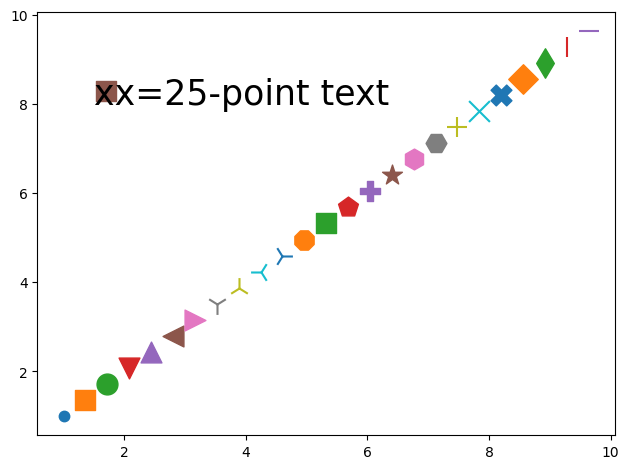

In [4]:
fig,ax = plt.subplots(1,1)

markers = [ '.', ',','o','v','^','<','>','1','2',
           '3','4','8','s','p','P','*','h','H',
           '+','x','X','D','d','|','_']
print("number markers =",len(markers))

#Draw all the markers
x = np.linspace(1,10,len(markers)+1)
for cnt in range(len(markers)):
    ax.scatter(x[cnt],x[cnt],s=225,marker=markers[cnt])

#Draw the square marker next to 25-point text.
ax.scatter(1.7,8.3,s=225,marker='s')
ax.text(1.5,8,'xx=25-point text',fontsize=25)
    
plt.tight_layout()
plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.02.png**

### Type of Image
This figure is a scatter plot demonstrating different marker shapes and a specific marker size using the Axes.scatter method. The plot includes a diagonal arrangement of markers and a text annotation used for visual comparison.

### Overall Summary
The plot displays the first 25 marker styles available in Matplotlib, each drawn at increasing x and y coordinates so they form a diagonal line. All markers are rendered at a size of 225 points squared. A square marker is placed near a 25‑point text label to illustrate how marker size relates to typographic point measurements.

### Detailed Description
The scatter plot contains a sequence of markers arranged from the lower left to the upper right, each representing one of the first 25 marker symbols supported by Matplotlib. All markers use a size value of 225, corresponding to a 25‑point by 25‑point area. Near the upper portion of the plot, a square marker is positioned next to a text label rendered at 25‑point font size. This placement visually compares the physical size of a marker defined by area in points squared with the height of text defined in typographic points.

### Purpose of the Image
The figure illustrates how marker shapes and marker sizes behave in Matplotlib’s scatter plots. It helps students understand the meaning of the marker size parameter s, how points squared relate to typographic points, and how different marker symbols appear when rendered at the same size.

## Color

One of the keyword arguments to the the [Axes.scatter](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.scatter.html?highlight=scatter#matplotlib.axes.Axes.scatter) method is **c**, which stands for color. This argument specifies the facecolor of the marker.

Another of the keyword arguments is **edgecolors**, which specifies the color, if any, that is applied to the edge of the markers.

Regarding the facecolor, here is a paraphrased quotation from the [documentation](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.scatter.html?highlight=scatter#matplotlib.axes.Axes.scatter)


The keyword argument **c** can be:

- a single color format string, or 
- a sequence of color specifications of length N, or 
- a sequence of N numbers to be mapped to colors using the cmap ...

These three options will be illustrated in the sections that follow.

### Single color format string

The following code illustrates the use of a single color format string to specify the color of the markers.

This code also sets the edge color on the markers to green.

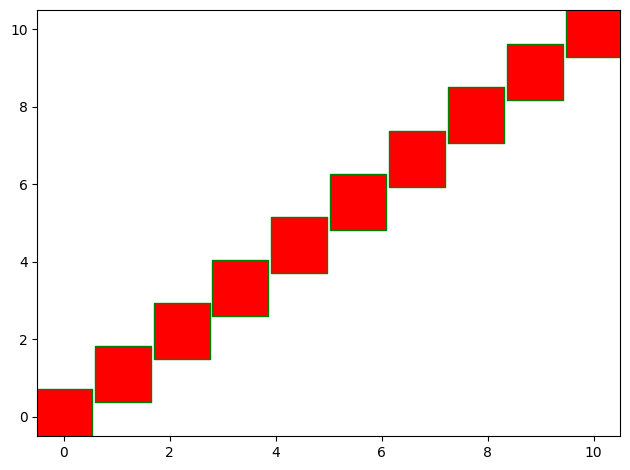

In [5]:
fig,ax0 = plt.subplots(1,1)

x = np.linspace(0,10,10)
y = x
ax0.scatter(x,y,s=40**2,marker='s',c='Red',edgecolors='Green')

plt.tight_layout()
plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.03.png**

### Type of Image
This figure is a scatter plot demonstrating the use of a single color format string for marker facecolor and a separate color for marker edges. The plot contains square markers arranged diagonally across the coordinate plane.

### Overall Summary
The plot shows a sequence of square markers positioned along a line where the x and y values increase together. Each marker uses a facecolor specified by a single color string and an edgecolor specified independently. The figure illustrates how the Axes.scatter method applies color and edgecolors to markers.

### Detailed Description
The scatter plot displays square markers placed from the lower left toward the upper right of the axes, following the relationship y = x. Each marker has a size defined by s = 40**2, producing a consistent visual area. The facecolor of all markers is set using a single Red color format string, while the edges of the markers are drawn in a contrasting Green color. The axes span from 0 to 10 on both the horizontal and vertical scales, and the markers appear evenly spaced along the diagonal.

### Purpose of the Image
The figure demonstrates how to specify marker facecolor using the c keyword argument and how to apply a distinct edge color using the edgecolors keyword argument in the Axes.scatter method. It provides a clear example of how color settings affect the appearance of markers in a scatter plot.

### Sequence of color specifications

The following code illustrates the use of a sequence of color specifications to specify the color of the markers.

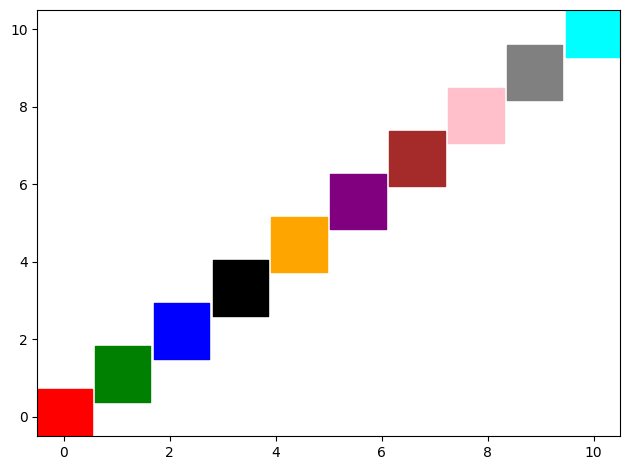

In [6]:
fig,ax0 = plt.subplots(1,1)

x = np.linspace(0,10,10)
y = x
ax0.scatter(x,y,s=40**2,marker='s',c=['red', 'green', 'blue', 'black',
                                      'orange', 'purple', 'brown', 
                                      'pink', 'gray', 'cyan'])

plt.tight_layout()
plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.04.png**

### Type of Image
This figure is a scatter plot demonstrating the use of a sequence of color specifications to assign different facecolors to markers. The plot contains square markers arranged diagonally across the coordinate plane.

### Overall Summary
The plot shows a set of square markers positioned along a line where the x and y values increase together. Each marker is assigned a different color from a provided list of color names. The figure illustrates how the Axes.scatter method applies a sequence of color specifications to markers.

### Detailed Description
The scatter plot displays square markers placed from the lower left toward the upper right of the axes, following the relationship y = x. Each marker has a size defined by s = 40**2, producing a consistent visual area. The facecolor of each marker is determined by a sequence of ten color names, resulting in a series of differently colored squares. The axes span from 0 to 10 on both the horizontal and vertical scales, and the markers appear evenly spaced along the diagonal.

### Purpose of the Image
The figure demonstrates how to specify marker facecolors using a sequence of color specifications with the c keyword argument in the Axes.scatter method. It provides a clear example of how supplying a list of color names results in each marker receiving a distinct color.

### Sequence of numbers using cmap

A [colormap](https://matplotlib.org/examples/color/colormaps_reference.html) is a set of colors taken as a group. Matplotlib provides several different colormaps, most of which progress smoothly from one color to another color with other colors in betweek. However, some progress from one color to another color in steps or blocks.

If you specify colors using a sequence of numbers with a color map, the low value will be associated with one end of the colormap and the high value will be associated with the other end of the color map. Values in between will be associated linearly with the colors between the two ends of the colormap.

Each colormap has a name. The colors in the map can be reversed by appending \_r to the name of the colormap.

The following code illustrates the specification of colors using a sequence of numbers and a reversed version of the colormap named **plasma**.

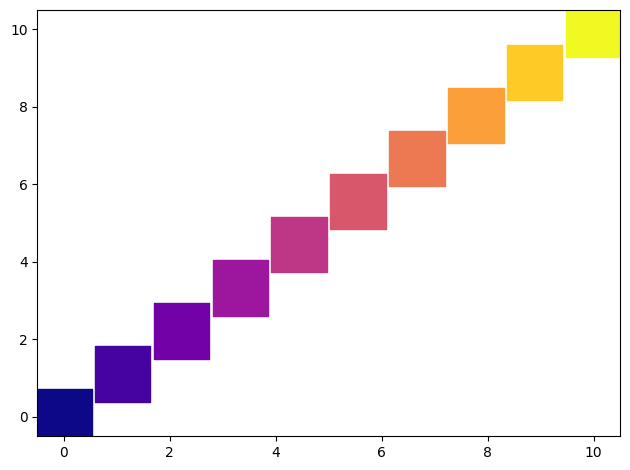

In [7]:
fig,ax0 = plt.subplots(1,1)

x = np.linspace(0,10,10)
y = x
colors = [10,9,8,7,6,5,4,3,2,1]
ax0.scatter(x,y,s=1600,marker='s',c=colors,cmap='plasma_r')

plt.tight_layout()
plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.05.png**

### Type of Image
This figure is a scatter plot demonstrating the use of a sequence of numeric values mapped through a reversed colormap to determine marker facecolors. The plot contains square markers arranged diagonally across the coordinate plane.

### Overall Summary
The plot shows a set of square markers positioned along a line where the x and y values increase together. Each marker receives its facecolor from a numeric sequence processed through the reversed version of the plasma colormap. The figure illustrates how the Axes.scatter method applies a colormap when the c argument is given a list of numbers.

### Detailed Description
The scatter plot displays square markers placed from the lower left toward the upper right of the axes, following the relationship y = x. Each marker has a size defined by s = 1600, producing large, easily visible squares. The facecolor of each marker is determined by a sequence of ten numeric values ranging from 10 down to 1. These values are mapped through the reversed plasma colormap, resulting in a smooth transition of colors across the diagonal. The axes span from 0 to 10 on both the horizontal and vertical scales, and the markers appear evenly spaced along the diagonal.

### Purpose of the Image
The figure demonstrates how to specify marker facecolors using a sequence of numeric values combined with a colormap through the c and cmap keyword arguments in the Axes.scatter method. It provides a clear example of how numeric inputs are mapped to colors and how reversing a colormap affects the resulting color progression.

## Colorbar

A [colorbar](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.colorbar.html#matplotlib.pyplot.colorbar) is a legend of sorts that shows the color associated with color values in an image.

The code required to add a colorbar differs depending on whether you are working with pyplot objects or axes objects. 

### A colorbar with pytlot object

The following code shows how to add a colorbar to a pyplot object. By default, the colorbar appears on the right and is the same height as the plot to which it refers. Note that in this case, the colorbar function does not require any arguments. It sets the default to the current image. 

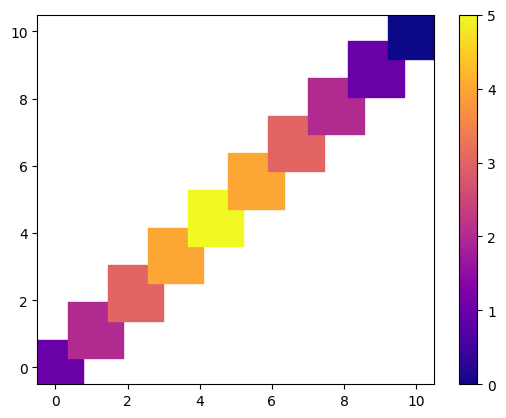

In [8]:
x = np.linspace(0,10,10)
y = x
colors = [1,2,3,4,5,4,3,2,1,0]
plt.scatter(x,y,s=1600,marker='s',c=colors,cmap='plasma')

plt.colorbar();  # add the colorbar

plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.06.png**

### Type of Image
This figure is a scatter plot demonstrating the use of numeric values mapped through a colormap, along with a colorbar that displays the mapping between numeric values and colors. The plot contains square markers arranged diagonally across the coordinate plane.

### Overall Summary
The plot shows a sequence of square markers positioned along a line where the x and y values increase together. Each marker receives its facecolor from a numeric sequence processed through the plasma colormap. A colorbar is displayed to the right of the plot, showing the correspondence between numeric values and the colors used in the markers.

### Detailed Description
The scatter plot displays square markers placed from the lower left toward the upper right of the axes, following the relationship y = x. Each marker has a size defined by s = 1600, producing large, easily visible squares. The facecolor of each marker is determined by a sequence of ten numeric values ranging from 1 up to 5 and back down to 0. These values are mapped through the plasma colormap, resulting in a smooth transition of colors across the diagonal. A vertical colorbar appears on the right side of the figure, labeled from 0 at the bottom to 5 at the top, indicating how numeric values correspond to colors. The axes span from 0 to 10 on both the horizontal and vertical scales.

### Purpose of the Image
The figure demonstrates how to specify marker facecolors using numeric values combined with a colormap through the c and cmap keyword arguments in the scatter function. It also illustrates how to add a colorbar to a pyplot object to show the mapping between numeric values and colors.

### A colorbar with an axes object

To add a colorbar to an axes object, you need to create another axes object and position it next to the plot to which it refers. The following code calls the [add_axes](http://matplotlib.org/2.0.2/api/figure_api.html?highlight=add_axes#matplotlib.figure.Figure.add_axes) method to add the new axes to the figure. The arguments specify the location and dimensions of the new axes object as ***left***, ***bottom***, ***width***, and ***height*** where all quantities are in fractions of the figure width and height. 

Then you need to draw the colorbar in the new axes. In this case, the colorbar method requires two arguments. The first argument specifies the image to which the colorbar applies. The image is the scatter plot in this code. The second argument is the axes object into which the colorbar will be drawn. That is the new axes object in this code.

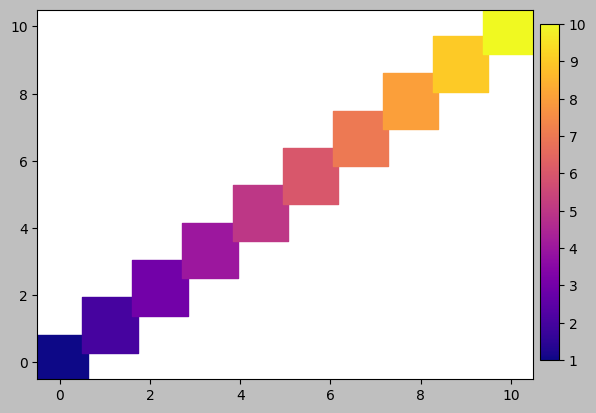

In [9]:
fig,ax0 = plt.subplots(1,1)
fig.set_facecolor('0.75')

x = np.linspace(0,10,10)
y = x
colors = [1,2,3,4,5,6,7,8,9,10]

#Create and save a reference to the scatter plot.
im = ax0.scatter(x,y,s=1600,marker='s',c=colors,cmap='plasma')

#Add new axes to the figure.
ax1 = fig.add_axes([0.91, 0.15, 0.03, 0.70])

#Draw a colorbar in the new axes.
fig.colorbar(im, cax=ax1)

plt.savefig("VisualizationPart04.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart04.07.png**

### Type of Image
This figure is a scatter plot that uses numeric values mapped through a colormap, along with a manually positioned colorbar drawn in a separate axes object. The plot contains square markers arranged diagonally across the coordinate plane.

### Overall Summary
The plot shows a sequence of square markers positioned along a line where the x and y values increase together. Each marker receives its facecolor from a numeric sequence processed through the plasma colormap. A separate axes object is added to the figure to hold the colorbar, which displays the mapping between numeric values and the colors used in the markers.

### Detailed Description
The scatter plot displays square markers placed from the lower left toward the upper right of the axes, following the relationship y = x. Each marker has a size defined by s = 1600, producing large, easily visible squares. The facecolor of each marker is determined by a sequence of ten numeric values ranging from 1 to 10. These values are mapped through the plasma colormap, resulting in a smooth transition of colors across the diagonal. A vertical colorbar appears in a separate axes positioned to the right of the main plot. The colorbar is labeled from 1 at the bottom to 10 at the top, indicating how numeric values correspond to colors. The figure background is a medium gray tone.

### Purpose of the Image
The figure demonstrates how to add a colorbar when working with an axes object by creating a new axes and drawing the colorbar inside it. It also illustrates how numeric values can be mapped to colors using a colormap and how the resulting colorbar provides a visual legend for interpreting those values.

### Side Note on tight_layout
The tight_layout function does not always handle colorbars well. Because a colorbar is drawn in a separate axes outside the main plotting area, tight_layout may not reserve enough space for it. As a result, the colorbar can be clipped, compressed, or overlap the main plot. This behavior is expected

##### --To be continued in the tutorial titled Visualization Exercises Part 5--

Author: Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: VisualizationPart04.ipynb

Revised: 03/15/26

Copyright 2018 Richard G. Baldwin

-end-
